# 04 — Trial-level spatiotemporal PCA on real T15 data
## Attempted vocalized speech vs passive listening

**Sharel's question:** if every complete trial is treated as one point, do attempted-speech trials and passive-listening trials occupy different parts of a shared neural space?

This notebook is deliberately separate from the existing word-centroid analysis. It does not average repetitions of the same word before PCA. Instead, each of the 308 real T15 trials becomes one point.

## Exact representation

For each trial we select the same half-open response window, `[0, 500)` ms. T15 has 10 ms bins and the configured `i6v` channel set has 64 channels, so one trial contains:

```text
50 time bins × 64 channels
            ↓ flatten (time-major; channel varies fastest)
one vector with 3,200 values
```

All trial vectors are pooled into one `308 × 3,200` matrix. One feature-wise scaler and one PCA are fitted to that matrix without using condition labels. Only after projection are points colored by condition.

In [1]:
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
if not (ROOT / 'pyproject.toml').exists():
    raise RuntimeError('Run this notebook from the repository root or notebooks directory.')
sys.path.insert(0, str(ROOT / 'src'))

from kunz_speech_geometry.config import load_config
from kunz_speech_geometry.geometry import centroid_distance, stratified_permutation_test
from kunz_speech_geometry.io import load_interleaved_mat
from kunz_speech_geometry.pca import fit_trial_spatiotemporal_pca
from kunz_speech_geometry.plotting import DEFAULT_COLORS
from kunz_speech_geometry.preprocess import smooth_and_baseline

config_path = Path(os.environ.get(
    'KUNZ_CONFIG', ROOT / 'configs' / 't15_interleaved_binnedtx.yaml'
))
if not config_path.is_absolute():
    config_path = ROOT / config_path
config = load_config(config_path)
seed = int(config['project']['random_seed'])
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 12, 'axes.labelsize': 10})
print(f'Configuration: {config_path.relative_to(ROOT)}')

Configuration: configs/t15_interleaved_binnedtx.yaml


## 1. Load and audit the real T15 trials

The public interleaved task is used because attempted and listening trials occur within the same recording blocks. The notebook stops with a clear instruction if the released `.mat` file has not yet been downloaded.

In [2]:
mat_path = ROOT / config['dataset']['mat_path']
if not mat_path.is_file():
    raise FileNotFoundError(
        f'Missing {mat_path}. Run: python3 scripts/reproduce.py --data-only'
    )

dataset = load_interleaved_mat(
    mat_path,
    feature=config['dataset']['feature'],
    channel_sets=config['dataset'].get('channel_sets'),
    epoch_ms=tuple(config['dataset']['epoch_ms']),
    block_center=config['dataset'].get('block_center', True),
).subset_conditions(config['dataset']['conditions']).validate()

print(f'rates [trial, time, channel]: {dataset.rates.shape}')
print(f'time range: {dataset.time_ms[0]:.0f} to {dataset.time_ms[-1]:.0f} ms')
print(f'bin width: {dataset.bin_width_ms:.0f} ms')
print(f'feature: {dataset.feature_name} ({dataset.units})')
print(f'participant: {dataset.trials.participant.iloc[0]}')

rates [trial, time, channel]: (308, 150, 64)
time range: -500 to 990 ms
bin width: 10 ms
feature: binnedTX_block_centered (counts/bin)
participant: T15


In [3]:
counts = (
    dataset.trials.groupby(['condition', 'word'])
    .size()
    .rename('n_trials')
    .unstack('condition')
)
display(counts)
assert counts.to_numpy().min() == counts.to_numpy().max() == 22
assert dataset.rates.shape == (308, 150, 64)
print('Balanced design: 154 trials per condition; 22 per word and condition.')

condition,attempted_vocalized,passive_listening
word,,
ban,22,22
choice,22,22
day,22,22
feel,22,22
kite,22,22
though,22,22
were,22,22


Balanced design: 154 trials per condition; 22 per word and condition.


## 2. Apply the existing preprocessing, then flatten each trial

This reuses the repository's existing choices: block centering in the loader, 60 ms Gaussian smoothing within each epoched trial, and per-trial/channel baseline subtraction. No existing analysis is changed.

The half-open `[0, 500)` convention is explicit here. The older `window_mask()` helper is inclusive, which would select 51 samples (`0` through `500`); Sharel's requested `T × n` construction uses exactly 50 samples (`0` through `490`).

In [4]:
pre = config['preprocessing']
processed = smooth_and_baseline(
    dataset,
    smoothing_sigma_ms=pre['smoothing_sigma_ms'],
    baseline_window_ms=pre['baseline_window_ms'],
    baseline_correct=pre['baseline_correct'],
)

window_start, window_stop = map(float, pre['analysis_window_ms'])
trial_window_mask = (processed.time_ms >= window_start) & (processed.time_ms < window_stop)
selected_times = processed.time_ms[trial_window_mask]

print(f'fixed half-open window: [{window_start:.0f}, {window_stop:.0f}) ms')
print(f'selected times: {selected_times[0]:.0f} ... {selected_times[-1]:.0f} ms')
print(f'time bins × channels: {trial_window_mask.sum()} × {processed.rates.shape[2]}')
print(f'flattened values per trial: {trial_window_mask.sum() * processed.rates.shape[2]:,}')
assert trial_window_mask.sum() == 50

fixed half-open window: [0, 500) ms
selected times: 0 ... 490 ms
time bins × channels: 50 × 64
flattened values per trial: 3,200


In [5]:
trial_pca = fit_trial_spatiotemporal_pca(
    processed.rates,
    trial_window_mask,
    n_components=config['pca']['n_components'],
    standardize_features=pre['standardize_channels'],
    random_state=seed,
)
labels = processed.trials['condition'].to_numpy()

print(f'flattened trial matrix: {trial_pca.vectors.shape}')
print(f'standardized matrix: {trial_pca.standardized_vectors.shape}')
print(f'PCA scores: {trial_pca.scores.shape}')
print(f'first 3 PCs explain: {trial_pca.explained_variance_ratio[:3].sum():.1%}')
print(f'first 10 PCs explain: {trial_pca.explained_variance_ratio.sum():.1%}')

flattened trial matrix: (308, 3200)
standardized matrix: (308, 3200)
PCA scores: (308, 10)
first 3 PCs explain: 13.5%
first 10 PCs explain: 27.1%


### What standardization means here

A flattened coordinate means one particular `(time bin, channel)` pair. Its mean and standard deviation are estimated across all 308 pooled trials. The same transformation is used for both conditions. Constant coordinates are safely mapped to zero.

In [6]:
nonconstant = trial_pca.scaler_scale > 0
scaling_audit = pd.Series({
    'pooled trials': trial_pca.vectors.shape[0],
    'flattened features': trial_pca.vectors.shape[1],
    'constant features': int((trial_pca.vectors.var(axis=0) == 0).sum()),
    'largest |standardized feature mean|': float(
        np.abs(trial_pca.standardized_vectors.mean(axis=0)).max()
    ),
})
display(scaling_audit.to_frame('value'))

,value
pooled trials,3.080000e+02
flattened features,3.200000e+03
constant features,0.000000e+00
largest |standardized feature mean|,1.077061e-15


## 3. How much variance do the shared PCs retain?

The 3D plot necessarily discards variance. The scree plot reports how much of the pooled standardized trial-to-trial variation is visible in each axis.

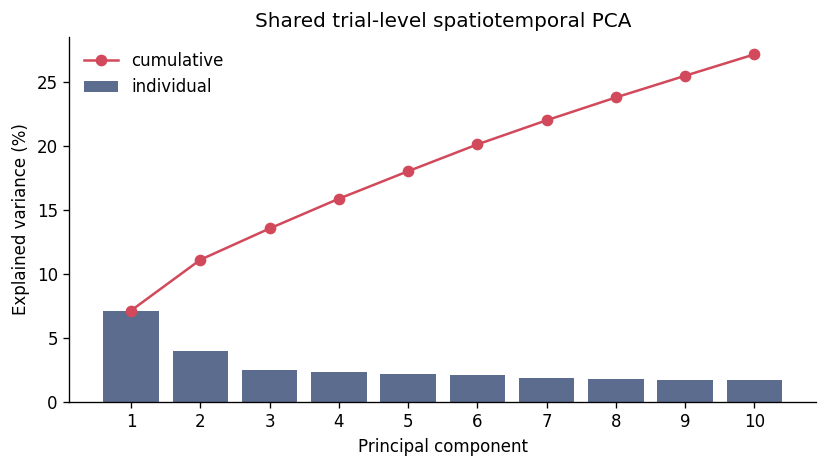

In [7]:
ratios = trial_pca.explained_variance_ratio
pcs = np.arange(1, len(ratios) + 1)
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(pcs, 100 * ratios, color='#5B6C8F', label='individual')
ax.plot(pcs, 100 * np.cumsum(ratios), 'o-', color='#D1495B', label='cumulative')
ax.set(
    xlabel='Principal component',
    ylabel='Explained variance (%)',
    title='Shared trial-level spatiotemporal PCA',
    xticks=pcs,
)
ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
plt.show()

## 4. The requested PC1/PC2/PC3 plot

Every small marker below is one real trial. Colors are applied only after the common scaler and PCA have been fitted. Large `X` markers show the condition centroids in the displayed 3D space.

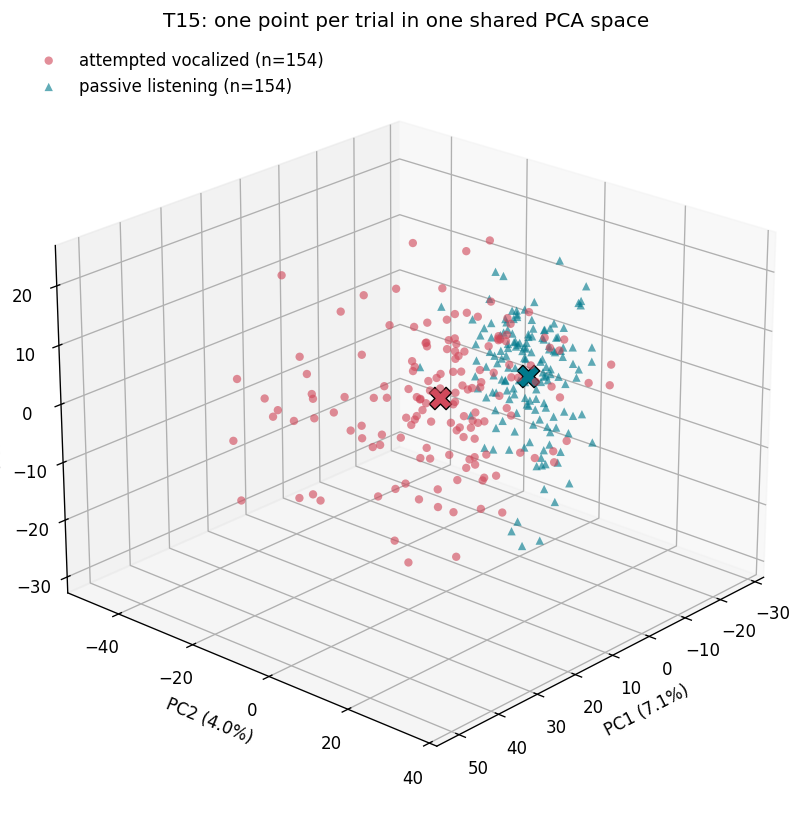

Generated figure: results/figures/t15_interleaved_binnedtx/mat_trial_spatiotemporal_pca_3d.png


In [8]:
condition_names = {
    'attempted_vocalized': 'attempted vocalized',
    'passive_listening': 'passive listening',
}
markers = {'attempted_vocalized': 'o', 'passive_listening': '^'}
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')
for condition in config['dataset']['conditions']:
    mask = labels == condition
    color = DEFAULT_COLORS[condition]
    ax.scatter(
        trial_pca.scores[mask, 0],
        trial_pca.scores[mask, 1],
        trial_pca.scores[mask, 2],
        s=25, alpha=0.62, color=color, marker=markers[condition],
        edgecolors='none', label=f'{condition_names[condition]} (n={mask.sum()})',
    )
    center = trial_pca.scores[mask, :3].mean(axis=0)
    ax.scatter(*center, s=180, color=color, marker='X', edgecolors='black', linewidths=0.8)

ax.set_xlabel(f'PC1 ({ratios[0]:.1%})')
ax.set_ylabel(f'PC2 ({ratios[1]:.1%})')
ax.set_zlabel(f'PC3 ({ratios[2]:.1%})')
ax.set_title('T15: one point per trial in one shared PCA space')
ax.view_init(elev=23, azim=42)
ax.legend(frameon=False, loc='upper left')
fig.tight_layout()

figure_dir = ROOT / config['outputs']['figure_dir']
figure_dir.mkdir(parents=True, exist_ok=True)
figure_path = figure_dir / 'mat_trial_spatiotemporal_pca_3d.png'
if config['outputs']['save_figures']:
    fig.savefig(figure_path, bbox_inches='tight', dpi=180)
plt.show()
print(f'Generated figure: {figure_path.relative_to(ROOT)}')

## 5. Quantify the condition shift without treating 3D as the full result

The visual plot retains only three axes. We therefore also compute the distance between condition centroids in all 3,200 standardized coordinates. A whole-trial permutation shuffles labels only within `session × block × word`, preserving the interleaved design and word balance. This tests a condition-centroid shift; it is not a held-out decoder.

In [9]:
distance_3d = centroid_distance(trial_pca.scores[:, :3], labels)
distance_full = centroid_distance(trial_pca.standardized_vectors, labels)
permutation = stratified_permutation_test(
    trial_pca.standardized_vectors,
    processed.trials,
    strata_columns=config['geometry']['permutation_strata'],
    n_permutations=config['geometry']['n_permutations'],
    random_state=seed,
)
summary = pd.Series({
    'n attempted trials': int((labels == 'attempted_vocalized').sum()),
    'n listening trials': int((labels == 'passive_listening').sum()),
    'flattened dimensions per trial': trial_pca.vectors.shape[1],
    'variance visible in PC1–PC3': trial_pca.explained_variance_ratio[:3].sum(),
    'condition-centroid distance in PC1–PC3': distance_3d,
    'condition-centroid distance in all standardized features': distance_full,
    'stratified permutation p-value': permutation.p_value,
    'exchangeable session × block × word strata': permutation.exchangeable_strata,
})
display(summary.to_frame('value'))

,value
n attempted trials,154.000000
n listening trials,154.000000
flattened dimensions per trial,3200.000000
variance visible in PC1–PC3,0.135277
condition-centroid distance in PC1–PC3,21.609742
condition-centroid distance in all standardized features,23.024246
stratified permutation p-value,0.001996
exchangeable session × block × word strata,35.000000


In [10]:
score_table = processed.trials.copy()
for component in range(trial_pca.scores.shape[1]):
    score_table[f'PC{component + 1}'] = trial_pca.scores[:, component]
table_dir = ROOT / config['outputs']['table_dir']
table_dir.mkdir(parents=True, exist_ok=True)
score_path = table_dir / 'mat_trial_spatiotemporal_pca_scores.csv'
score_table.to_csv(score_path, index=False)
display(score_table[['trial_id', 'condition', 'word', 'block', 'PC1', 'PC2', 'PC3']].head())
print(f'Exported one row per trial: {score_path.relative_to(ROOT)}')

,trial_id,condition,word,block,PC1,PC2,PC3
0,t15.2024.06.14_trial_0000,attempted_vocalized,were,3,8.113395,-16.574399,9.020341
1,t15.2024.06.14_trial_0003,attempted_vocalized,ban,3,15.824098,-7.209301,19.267002
2,t15.2024.06.14_trial_0009,passive_listening,feel,3,0.024822,-2.344694,1.252340
3,t15.2024.06.14_trial_0012,attempted_vocalized,kite,3,6.029587,-12.275979,9.125514
4,t15.2024.06.14_trial_0014,passive_listening,ban,3,-9.184595,1.777801,-4.102942


Exported one row per trial: results/tables/t15_interleaved_binnedtx/mat_trial_spatiotemporal_pca_scores.csv


## Interpretation and limits

- A point is one independent trial, not one electrode, time bin, or word average.
- Separation means the full time-by-channel patterns differ systematically between attempted production and passive listening in this T15 session.
- It does **not** isolate inner speech or motor intent. The conditions also differ in movement, auditory input, timing, preparation, and possibly global neural gain.
- PCA and standardization were fitted on these same trials. The graph is descriptive, not an estimate of performance on unseen trials. A decoder requires nested, block-aware cross-validation.
- The 3D plot shows only the variance retained by PC1–PC3; the permutation statistic is computed in the complete 3,200-dimensional standardized space.
- Because the interleaved archive mixes conditions within blocks, it is better suited to this direct contrast than the separately blocked isolated-behavior archive, though block diagnostics are still needed.

## How this differs from the earlier notebooks

| Notebook/view | One point represents | Input dimensions before PCA | Main question |
|---|---|---:|---|
| Word-centroid geometry | one word × condition average | 64 channels | Does word geometry change across conditions? |
| Time-resolved trajectory | one condition mean at one time | 64 channels | How does the average population state evolve? |
| **This notebook** | **one complete trial** | **50 times × 64 channels = 3,200** | **Do individual attempted and listening trials form different clouds?** |

These are complementary descriptions, not competing versions of the same PCA.